# **CODA (v2.0.0) Tutorial 4 — Three Global-Alignment Modes (Rigid, Similarity, Weak-Affine)**

> **Goal of Tutorial 4**:  Demonstrate the use of CODA’s three global alignment modes—rigid (Mode 1), similarity (Mode 2), and weak-affine (Mode 3)—across different deformation scenarios.

## **Environment setup & imports**

In [1]:
from CODA.Alignment import *
from CODA.Preprocessing import *
from CODA.RGBgenerator import *
from CODA.utils import *
from CODA.Cross_correlation import *
from CODA.Common_domain import *

D:\Anaconda\envs\CODA_test\lib\site-packages\louvain\__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


* You can download the data required for this tutorial here: [Example data 4](<https://drive.google.com/drive/folders/18wC5MrAaURZX0oUf5i9z2ihXQ8JlOUeW?usp=drive_link>).

* After downloading, place the files in the same directory as this notebook (`Tutorial 4 (Global alignment).ipynb`).

In [2]:
adata_73 = sc.read_h5ad('151673_with_distortion.h5ad')
adata_76 = sc.read_h5ad('151676.h5ad')

### Data preprocessing
We integrate per-slice AnnData objects with **BBKNN** and compute a 3D **UMAP** embedding grouped by `slice_id`.  
For detailed preprocessing steps and parameter choices, see **Tutorial 1**.

In [3]:
cfg = PreprocessConfig(
    integrate="bbknn",  
    use_hvg=True, n_top_genes=3000,
    normalize_target=1e4, log1p=True,
    scale_max_value=10.0, n_pcs=30,
    seed=0, num_threads=1
)
sti = STIntegrator(cfg)

merged = sti.preprocess_and_integrate([adata_73, adata_76], batch_names=["73","76"])
emb, emb_rgb01, split_emb, split_rgb = sti.embed(merged, method="umap", n_components=3)

embedding_73 = split_emb["73"]
embedding_76 = split_emb["76"]
embedding_73_rgb = split_rgb["73"] 
embedding_76_rgb = split_rgb["76"]

### Clustering
For detailed clustering steps and parameter choices, see **Tutorial 1**.

In [4]:
sc.tl.louvain(merged, random_state=0, key_added="louvain", resolution=2)

bbknn_73 = merged[merged.obs['batch']=='73']
bbknn_76 = merged[merged.obs['batch']=='76']

adata_73.obs["louvain"] = merged.obs["louvain"][
    merged.obs_names.astype(str).str.endswith("-73")
].reset_index(drop=True).to_numpy()

adata_76.obs["louvain"] = merged.obs["louvain"][
    merged.obs_names.astype(str).str.endswith("-76")
].reset_index(drop=True).to_numpy()

### **Case I: Rotation Distortion** → **Mode I (rigid)**
Use when the main mismatch is **rotation + translation** (same pixel scale, no shear).  
Keeps distances and scale intact; ideal for serial sections or same-platform pairs.

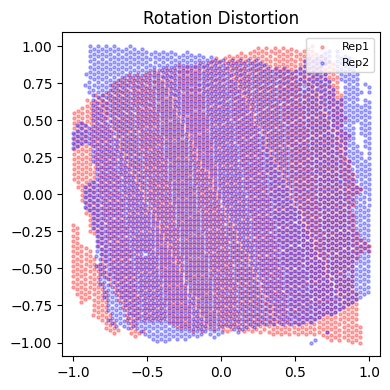

In [5]:
colors = ['red', 'blue']
labels = ['Rep1', 'Rep2']
adatas = [adata_76,adata_73]
coord_keys = ['spatial_norm','spatial_rotated_180']

plt.figure(figsize=(4, 4))
for adata, key, color, label in zip(adatas, coord_keys, colors, labels):
    coords = adata.obsm[key]
    plt.scatter(coords[:, 0], coords[:, 1], s=5, alpha=0.3, label=label, color=color)

plt.title("Rotation Distortion")
plt.legend(loc='upper right', fontsize=8)
plt.axis('equal')
plt.tight_layout()
plt.show()

#### **Mode I** → set `mode="G1"`

In [6]:
src_xy = adata_73.obsm['spatial_rotated_180']
dst_xy = adata_76.obsm['spatial_norm']

res = align_points(
    src_xy, dst_xy,
    src_feat=None, dst_feat=None,     
    mode="G1", if_labeled=True,
    label_key="louvain",
    src_adata=adata_73,
    dst_adata=adata_76
)
adata_73.obsm['spatial_aligned_g1'] = res['aligned']

Scatter plot of the two slices **After global alignment (Mode I)**.

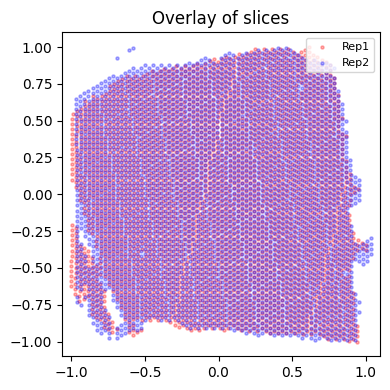

In [7]:
adatas = [adata_76,adata_73]

coord_keys = ['spatial_norm','spatial_aligned_g1']

plt.figure(figsize=(4, 4))
for adata, key, color, label in zip(adatas, coord_keys, colors, labels):
    coords = adata.obsm[key]
    plt.scatter(coords[:, 0], coords[:, 1], s=5, alpha=0.3, label=label, color=color)

plt.title("Overlay of slices")
plt.legend(loc='upper right', fontsize=8)
plt.axis('equal')
plt.tight_layout()
plt.show()

### **Case II: Scaling Distortion** → **Mode II (similarity)**
Use when there is a **uniform scale difference** (magnification) in addition to rotation/translation.  
Corrects global size mismatch without introducing shear; don’t use G1 (underfits) or G2+ (may overfit).

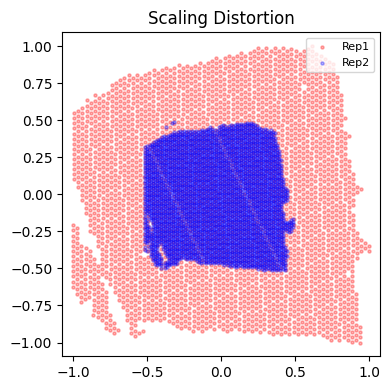

In [8]:
colors = ['red', 'blue']
labels = ['Rep1', 'Rep2']
adatas = [
    adata_76,
    adata_73
]
coord_keys = ['spatial_norm','spatial_scaled']

plt.figure(figsize=(4, 4))
for adata, key, color, label in zip(adatas, coord_keys, colors, labels):
    coords = adata.obsm[key]
    plt.scatter(coords[:, 0], coords[:, 1], s=5, alpha=0.3, label=label, color=color)

plt.title("Scaling Distortion")
plt.legend(loc='upper right', fontsize=8)
plt.axis('equal')
plt.tight_layout()
plt.show()

#### **Mode II** → set `mode="G2"`

In [9]:
src_xy = adata_73.obsm['spatial_scaled']
dst_xy = adata_76.obsm['spatial_norm']

res = align_points(
    src_xy, dst_xy,
    src_feat=None, dst_feat=None,     
    mode="G2", if_labeled=True,
    label_key="louvain",
    src_adata=adata_73,
    dst_adata=adata_76
)
adata_73.obsm['spatial_aligned_g2'] = res['aligned']

Scatter plot of the two slices **After global alignment (Mode II)**.

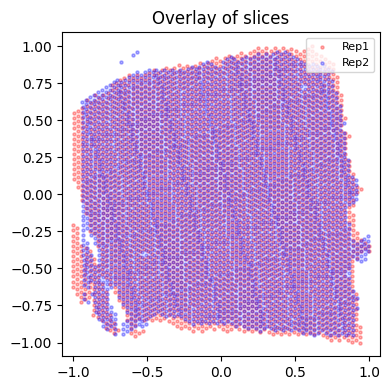

In [10]:
adatas = [adata_76,adata_73]
coord_keys = ['spatial_norm','spatial_aligned_g2']

plt.figure(figsize=(4, 4))
for adata, key, color, label in zip(adatas, coord_keys, colors, labels):
    coords = adata.obsm[key]
    plt.scatter(coords[:, 0], coords[:, 1], s=5, alpha=0.3, label=label, color=color)

plt.title("Overlay of slices")
plt.legend(loc='upper right', fontsize=8)
plt.axis('equal')
plt.tight_layout()
plt.show()

### **Case III: Skew Distortion** → **MODE III (weak-affine)**
Use when you see **mild shear / anisotropic scaling** from imaging or tissue handling.  
Allows limited non-rigid global deformation; prefer only when needed and follow with local refinement (e.g., LDDMM).

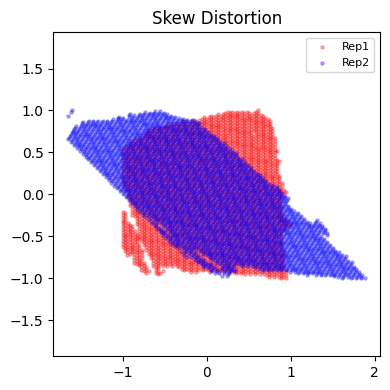

In [11]:
adatas = [adata_76,adata_73]
coord_keys = ['spatial_norm','spatial_skew']

plt.figure(figsize=(4, 4))
for adata, key, color, label in zip(adatas, coord_keys, colors, labels):
    coords = adata.obsm[key]
    plt.scatter(coords[:, 0], coords[:, 1], s=5, alpha=0.3, label=label, color=color)

plt.title("Skew Distortion")
plt.legend(loc='upper right', fontsize=8)
plt.axis('equal')
plt.tight_layout()
plt.show()

#### **Mode III** → set `mode="G2+"`

In [12]:
src_xy = adata_73.obsm['spatial_skew']
dst_xy = adata_76.obsm['spatial_norm']

res = align_points(
    src_xy, dst_xy,
    src_feat=None, dst_feat=None,     
    mode="G2+", if_labeled=True,
    label_key="louvain",
    src_adata=adata_73,
    dst_adata=adata_76
)
adata_73.obsm['spatial_aligned_g2p'] = res['aligned']

Scatter plot of the two slices **After global alignment (Mode III)**.

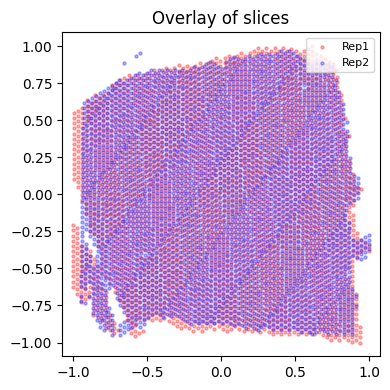

In [13]:
adatas = [adata_76,adata_73]
coord_keys = ['spatial_norm','spatial_aligned_g2p']

plt.figure(figsize=(4, 4))
for adata, key, color, label in zip(adatas, coord_keys, colors, labels):
    coords = adata.obsm[key]
    plt.scatter(coords[:, 0], coords[:, 1], s=5, alpha=0.3, label=label, color=color)

plt.title("Overlay of slices")
plt.legend(loc='upper right', fontsize=8)
plt.axis('equal')
plt.tight_layout()
plt.show()